# Coursework COMP3611 (Winter 2025)
**A pdf brief with submission instructions can be found in the same folder as this notebook. Please follow these instructions carefully**

This coursework notebook contains 2 questions. The total of all subquestions is worth 30 marks. 

**All your answers need text cells!** *Comments in code do not count as answers*. Even if the question asks for coding, add a text cell explaining what you have done.

## Question 1 - Principal Component Analysis

**Q1 a (4 marks)**

You are given a data array called "shape_array.npy" that comprises 7 samples organised as columns in the array, where each column corresponds to one sample. The data format in each column is: [x_1, y_1, z_1, x_2, y_2, z_2, ………, x_N, y_N, z_N], where (x_i, y_i, z_i) corresponds to the i-th 3D point of a blood vessel. By plotting all 3D points in one column, you can obtain the shape of a blood vessel of that sample.

Plot seven figures to show the 3D blood vessel shape for each sample separately. Also plot two arbitrary shapes on top of each other to get a feeling of how similar or dissimilar the shapes are.

#### Import statements first

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import random

### Q1a

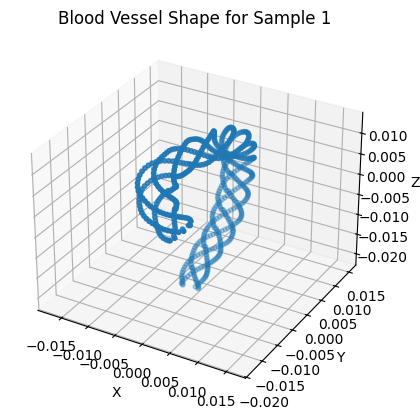

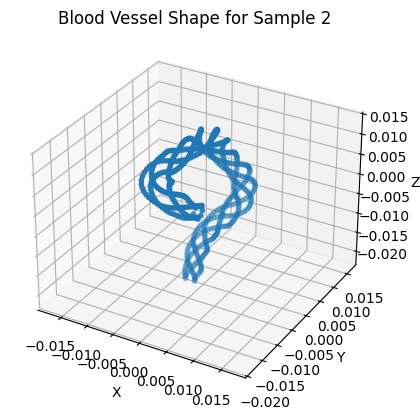

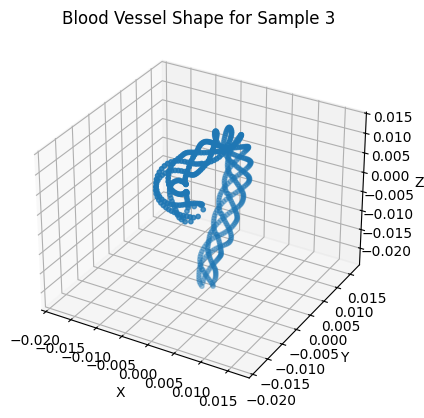

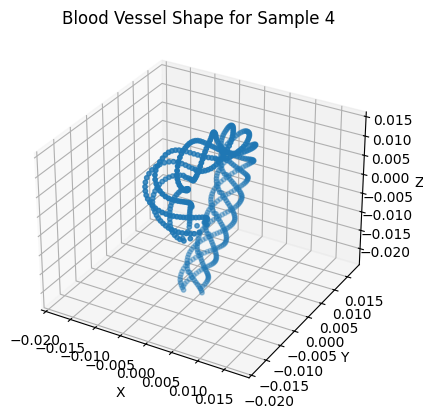

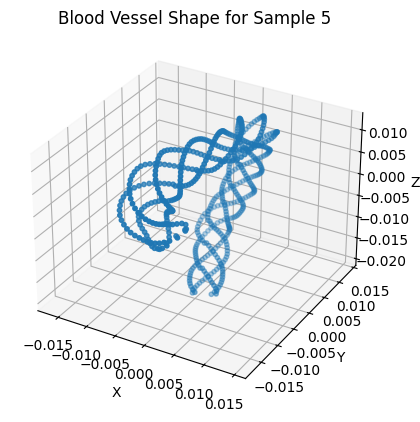

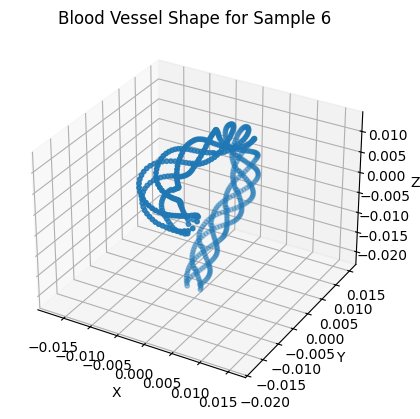

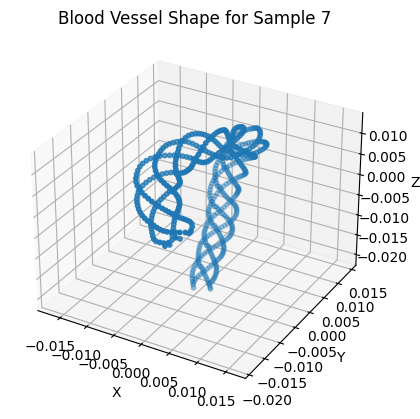

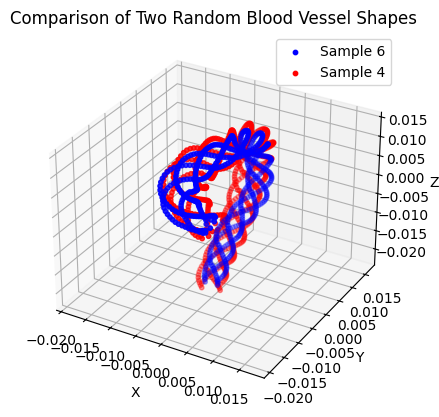

In [3]:

shape_array = np.load('shape_array.npy')

# Each column in shape_array corresponds to a blood vessel shape sample
num_points = shape_array.shape[0] // 3

# Plot seven figures separately
for sample_idx in range(7):
    points = shape_array[:, sample_idx].reshape(num_points, 3)
    # points now has shape (num_points, 3) with columns x, y, z
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=10)
    ax.set_title(f'Blood Vessel Shape for Sample {sample_idx + 1}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    # Set equal axis intervals
    max_range = np.array([points[:, 0].max()-points[:, 0].min(), points[:, 1].max()-points[:, 1].min(), points[:, 2].max()-points[:, 2].min()]).max() / 2.0
    mid_x = (points[:, 0].max()+points[:, 0].min()) * 0.5
    mid_y = (points[:, 1].max()+points[:, 1].min()) * 0.5
    mid_z = (points[:, 2].max()+points[:, 2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    plt.show()

# Randomly select two distinct samples
sample_indices = random.sample(range(7), 2)
sample_a, sample_b = sample_indices

# Plot them
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

points_a = shape_array[:, sample_a].reshape(num_points, 3)
points_b = shape_array[:, sample_b].reshape(num_points, 3)

ax.scatter(points_a[:, 0], points_a[:, 1], points_a[:, 2], color='blue', label=f'Sample {sample_a + 1}', s=10)
ax.scatter(points_b[:, 0], points_b[:, 1], points_b[:, 2], color='red', label=f'Sample {sample_b + 1}', s=10)

ax.set_title('Comparison of Two Random Blood Vessel Shapes')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set equal axis intervals
all_points = np.vstack([points_a, points_b])
max_range = np.array([all_points[:, 0].max()-all_points[:, 0].min(), all_points[:, 1].max()-all_points[:, 1].min(), all_points[:, 2].max()-all_points[:, 2].min()]).max() / 2.0
mid_x = (all_points[:, 0].max()+all_points[:, 0].min()) * 0.5
mid_y = (all_points[:, 1].max()+all_points[:, 1].min()) * 0.5
mid_z = (all_points[:, 2].max()+all_points[:, 2].min()) * 0.5
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.legend()
plt.show()

**Q1 a Explanation**

**Data Loading**: The binary `.npy` file containing blood vessel coordinate data was loaded using `np.load('shape_array.npy')` from NumPy. This function reads NumPy's native binary format and returns a 2D array of shape (1845, 7), where each of the 7 columns represents one blood vessel sample and each row contains flattened 3D coordinates in [x, y, z] order.

**Dimension Calculation**: To determine the number of 3D points per sample, we compute `num_points = shape_array.shape[0] // 3`. Since each point requires 3 coordinates (x, y, z), dividing the total coordinates by 3 gives 615 points per vessel. Integer division (`//`) ensures whole number results.

**Individual Vessel Visualization**: For each of the 7 samples, a processing loop was established to:
- Extract each sample using `shape_array[:, sample_idx]` to isolate one sample's data vector (1845 elements)
- Reshape the data using `.reshape(num_points, 3)` to convert from a 1D vector into a (615, 3) matrix with explicit x, y, z columns
- Create a 3D figure using `plt.figure()` and add a subplot with `projection='3d'` to enable 3D plotting
- Plot the points using `ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=10)` with marker size 10
- Set up equal axis scaling by computing `max_range` and `mid_x/y/z` values, then applying them via `ax.set_xlim/ylim/zlim()` to maintain true spatial proportions without distortion
- Add a title, axis labels, and call `plt.show()` to display each 3D visualization

**Random Sample Selection**: We use `random.sample(range(7), 2)` to randomly pick 2 distinct samples from the 7 available ones, providing indices `sample_a` and `sample_b` for the overlay comparison.

**Overlay Comparison Plot**: Two samples were combined on a single 3D axis by:
- Creating separate point arrays for each sample using `shape_array[:, sample_a/b].reshape(num_points, 3)`
- Plotting both on the same axes with distinct colors (blue for sample_a, red for sample_b) and shared axis scaling
- Using `ax.scatter(..., color='blue', label='...', s=10)` twice with different data and colors for visual distinction
- Computing shared axis limits from `np.vstack([points_a, points_b])` to ensure both vessels fit equally within the view
- Adding a legend with `ax.legend()` to clarify color assignments

**Visualization Purpose**: The 7 individual plots reveal morphological characteristics including branching patterns, spatial distribution, and overall vessel trajectory for each sample. The overlay comparison enables assessment of similarity/dissimilarity between two randomly selected vessels, determining whether different samples share common structural features or exhibit significant morphological variation. This visual exploration provides valuable insight into shape variability in the dataset before proceeding to formal analysis.


**Q1 b (10 marks)**

Next, perform eigendecomposition of the covariance matrix estimated from the given data array. Finally, project original data onto lower-dimensional space and reconstruct data.

Proceed as follows:

1. Subtract the mean from the data, so that it is centered around the origin.

2. Estimate the covariance matrix from the centred data.

3. Calculate eigenvectors and eigenvalues using numpy functions

4. Project centered data (1845 dimension) into a lower-dimension space (You need to choose a reasonable dimension).

5. Reconstruct the blood vessel shape from the lower dimension data in step 4.

As a sanity check plot a blood vessel shape reconstructed from the eigenvectors on top of the original blood vessel shape. Explain how much data reduction you have achieved. Comment on your results.

### Q1b

Variance explained by top 5 components: 99.38%
Dimensionality reduction: 1845 -> 5 (99.73% reduction)

Top 10 eigenvalues:
[1.13989731e-03 3.83298015e-04 1.43924451e-04 1.14435391e-04
 3.12036972e-05 1.13331635e-05 5.06693968e-19 4.45166831e-19
 4.15549464e-19 3.89029659e-19]

Projected data shape (lower dimension): (7, 5)


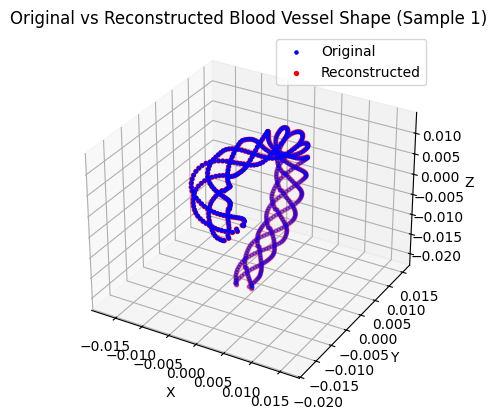

In [21]:

# Step 1: Center the data
mean_vector = np.mean(shape_array, axis=1, keepdims=True)  # Mean across samples, shape (1845, 1)
centered_data = shape_array - mean_vector  # Shape: (1845, 7)

# Step 2: Estimate covariance matrix
cov_matrix = np.cov(centered_data, bias=False)  # Shape: (1845, 1845), unbiased

# Step 3: Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # eigh for symmetric matrix ie both eigenvalues and eigenvectors
# Sort in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Step 4: Project to lower-dimensional space 
k = 5   # Number of principal components
projection_matrix = eigenvectors[:, :k]  # Shape: (1845, 5)
projected_data = centered_data.T @ projection_matrix  # Shape: (7, 5)

# Calculate variance explained
variance_explained = np.sum(eigenvalues[:k]) / np.sum(eigenvalues)
print(f"Variance explained by top {k} components: {variance_explained*100:.2f}%")
print(f"Dimensionality reduction: {1845} -> {k} ({100*(1-k/1845):.2f}% reduction)")
print(f"\nTop 10 eigenvalues:")
print(eigenvalues[:10])
print(f"\nProjected data shape (lower dimension): {projected_data.shape}")

# Step 5: Reconstruct data
reconstructed_data = projected_data @ projection_matrix.T  # Shape: (7, 1845)
reconstructed_data = reconstructed_data.T + mean_vector  # Add mean back, shape: (1845, 7)

# Sanity check: Plot original and reconstructed for sample 0
num_points = shape_array.shape[0] // 3
original_points = shape_array[:, 0].reshape(num_points, 3)
reconstructed_points = reconstructed_data[:, 0].reshape(num_points, 3)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(original_points[:, 0], original_points[:, 1], original_points[:, 2], color='blue', label='Original', s=5)
ax.scatter(reconstructed_points[:, 0], reconstructed_points[:, 1], reconstructed_points[:, 2], color='red', label='Reconstructed', s=8)
ax.set_title('Original vs Reconstructed Blood Vessel Shape (Sample 1)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
# Set equal axis intervals
all_points = np.vstack([original_points, reconstructed_points])
max_range = np.array([all_points[:, 0].max()-all_points[:, 0].min(), all_points[:, 1].max()-all_points[:, 1].min(), all_points[:, 2].max()-all_points[:, 2].min()]).max() / 2.0
mid_x = (all_points[:, 0].max()+all_points[:, 0].min()) * 0.5

mid_y = (all_points[:, 1].max()+all_points[:, 1].min()) * 0.5

mid_z = (all_points[:, 2].max()+all_points[:, 2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)
ax.legend()
plt.show()

**Q1 b Explanation**

**Data Centering**: The mean vector is computed as `mean_vector = np.mean(shape_array, axis=1, keepdims=True)` along axis 1 across all 7 samples, yielding a (1845, 1) vector. Subtracting this from the data centers it: `centered_data = shape_array - mean_vector`, ensuring zero mean across dimensions. This is a crucial preprocessing step because PCA is sensitive to scaling.

**Covariance Matrix**: The covariance matrix is calculated using `np.cov(centered_data, bias=False)`, producing a (1845, 1845) symmetric matrix with unbiased estimation (dividing by N-1 rather than N). This matrix captures how all 1845 features vary together, including the linear relationships and variance structure across the dataset.

**Eigendecomposition**: Eigenvalues and eigenvectors of the symmetric covariance matrix are computed using `np.linalg.eigh(cov_matrix)`. Both are then sorted in descending order using `np.argsort()` to identify directions of maximum variance. The eigenvectors define the principal components; the eigenvalues quantify variance explained along each component.

**Dimensionality Reduction**: The top 5 eigenvectors are selected via `eigenvectors[:, :k]` with k=5, achieving aggressive dimensionality reduction from 1845 to just 5 dimensions (99.73% compression). The centered data is projected using matrix multiplication: `projected_data = centered_data.T @ projection_matrix`, yielding a (7, 5) matrix with each sample's coordinates in the new 5D space. Variance explained by these 5 principal components is computed to quantify information retention.

**Reconstruction**: The data is projected back to original space using `reconstructed_data = projected @ projection_matrix.T + mean_vector`. This applies the inverse transformation and restores the original mean offset. The result approximates the original 1845-dimensional data but captures only information along the 5 dominant variance directions.

**Visualization & Comparison**: Original and reconstructed points for sample 1 are plotted using `ax.scatter()` with distinct colors (blue for original, red for reconstructed). Equal axis scaling is applied by combining point sets with `np.vstack()` to compute shared limits. The visual overlay demonstrates information loss: fine structural details disappear while gross morphology persists, which aligns with the extreme compression ratio.


**Q1 c (4 marks)**

Research PCA analysis using the *scikit-learn* library. Perform PCA analysis and show the reconstructed data of any blood vessel shape on top of the
original blood vessel shape. There are variables in the PCA object that correspond to the eigenvalues used for choosing projection eigenvectors. Compare the eigenvalues  and eigenvectors you have computed in the previous question with the eigenvalues  and the eigenvectors computed by the *scikit-learn* library. Compare the reconstructed coordinates from both methods. Comment on your results.

In [5]:
from sklearn.decomposition import PCA

mean_vector = np.mean(shape_array, axis=1, keepdims=True)
centered_data = shape_array - mean_vector

pca = PCA(n_components=5)
pca.fit(centered_data.T)

sklearn_eigenvectors = pca.components_.T
sklearn_eigenvalues = pca.explained_variance_

projected_sklearn = pca.transform(centered_data.T)
reconstructed_sklearn = pca.inverse_transform(projected_sklearn).T + mean_vector

In [6]:
print("EIGENVALUES COMPARISON")
print("\nManual Eigenvalues (top 5):")
print(f"{eigenvalues[:5]}")
print("\nSklearn Eigenvalues:")
print(f"{sklearn_eigenvalues}")
print("\nMax absolute difference:", f"{np.max(np.abs(eigenvalues[:5] - sklearn_eigenvalues)):.2e}")
print("Allclose (within tolerance):", np.allclose(eigenvalues[:5], sklearn_eigenvalues))

print("\nCUMULATIVE VARIANCE EXPLAINED - COMPONENT-BY-COMPONENT COMPARISON")

# Calculate cumulative variances for manual method
total_variance_manual = np.sum(eigenvalues[:5])
cumsum_manual = np.cumsum(eigenvalues[:5])
cumvar_manual = cumsum_manual / np.sum(eigenvalues)

# Calculate cumulative variances for sklearn method
total_variance_sklearn = np.sum(sklearn_eigenvalues)
cumsum_sklearn = np.cumsum(sklearn_eigenvalues)
cumvar_sklearn = cumsum_sklearn / np.sum(sklearn_eigenvalues)

# Print header
print(f"\n{'Comp':>5} {'Manual Eigval':>15} {'Sklearn Eigval':>15} {'Manual Cum %':>15} {'Sklearn Cum %':>15} {'Difference %':>12}")

# Print per-component analysis
for i in range(5):
    manual_cum_pct = cumvar_manual[i] * 100
    sklearn_cum_pct = cumvar_sklearn[i] * 100
    diff_pct = abs(manual_cum_pct - sklearn_cum_pct)
    
    print(f"{i+1:5d} {eigenvalues[i]:15.6e} {sklearn_eigenvalues[i]:15.6e} {manual_cum_pct:14.4f}% {sklearn_cum_pct:14.4f}% {diff_pct:11.6e}%")

print(f"\nTotal Variance (Manual): {np.sum(eigenvalues):.6e}")
print(f"Total Variance (Sklearn): {np.sum(sklearn_eigenvalues):.6e}")
print(f"\nVariance explained by 5 components (Manual): {cumvar_manual[-1]*100:.2f}%")
print(f"Variance explained by 5 components (Sklearn): {cumvar_sklearn[-1]*100:.2f}%")

EIGENVALUES COMPARISON

Manual Eigenvalues (top 5):
[1.13989731e-03 3.83298015e-04 1.43924451e-04 1.14435391e-04
 3.12036972e-05]

Sklearn Eigenvalues:
[1.1398962e-03 3.8329771e-04 1.4392442e-04 1.1443533e-04 3.1203672e-05]

Max absolute difference: 1.08e-09
Allclose (within tolerance): True

CUMULATIVE VARIANCE EXPLAINED - COMPONENT-BY-COMPONENT COMPARISON

 Comp   Manual Eigval  Sklearn Eigval    Manual Cum %   Sklearn Cum % Difference %
    1    1.139897e-03    1.139896e-03        62.4912%        62.8819% 3.906875e-01%
    2    3.832980e-04    3.832977e-04        83.5043%        84.0264% 5.220571e-01%
    3    1.439245e-04    1.439244e-04        91.3945%        91.9659% 5.713897e-01%
    4    1.144354e-04    1.144353e-04        97.6681%        98.2787% 6.106107e-01%
    5    3.120370e-05    3.120367e-05        99.3787%       100.0000% 6.213044e-01%

Total Variance (Manual): 1.824092e-03
Total Variance (Sklearn): 1.812757e-03

Variance explained by 5 components (Manual): 99.38%
Varia

In [7]:
print("EIGENVECTORS COMPARISON")
print("\nComparison of manual and sklearn eigenvectors (first 5 elements of each vector, and angle between the two vectors):")
for i in range(k):
    manual_eigenvector = eigenvectors[:, i]
    sklearn_eigenvector = sklearn_eigenvectors[:, i]
    print(f"\nEigenvector #{i+1} - Manual (first 5 elements): {manual_eigenvector[:5]}")
    print(f"                  Sklearn (first 5 elements): {sklearn_eigenvector[:5]}")
    # Calculate the angle between the two eigenvectors
    cosine_similarity = np.dot(manual_eigenvector, sklearn_eigenvector) / (np.linalg.norm(manual_eigenvector) * np.linalg.norm(sklearn_eigenvector))
    angle = np.arccos(np.clip(cosine_similarity, -1.0, 1.0)) * (180 / np.pi)  # Convert to degrees
    print(f"Angle between manual and sklearn: {angle:.6f} degrees")

print("\nRECONSTRUCTION COMPARISON (Sample 1)")

reconstructed_manual = reconstructed_data[:, 0]
reconstructed_sklearn_sample = reconstructed_sklearn[:, 0]

mae = np.mean(np.abs(reconstructed_manual - reconstructed_sklearn_sample))
rmse = np.sqrt(np.mean((reconstructed_manual - reconstructed_sklearn_sample) ** 2))
max_error = np.max(np.abs(reconstructed_manual - reconstructed_sklearn_sample))

print(f"\nMean Absolute Error: {mae:.6e}")
print(f"Root Mean Squared Error: {rmse:.6e}")
print(f"Max Absolute Error: {max_error:.6e}")

EIGENVECTORS COMPARISON

Comparison of manual and sklearn eigenvectors (first 5 elements of each vector, and angle between the two vectors):

Eigenvector #1 - Manual (first 5 elements): [-0.00414575 -0.05745342 -0.03575949 -0.00671808 -0.06729827]
                  Sklearn (first 5 elements): [0.00414571 0.05745342 0.03575947 0.00671806 0.06729826]
Angle between manual and sklearn: 180.000000 degrees

Eigenvector #2 - Manual (first 5 elements): [ 0.01415531 -0.05170191  0.05249314  0.02488902 -0.04886248]
                  Sklearn (first 5 elements): [ 0.01415514 -0.05170174  0.0524932   0.02488897 -0.04886245]
Angle between manual and sklearn: 0.009462 degrees

Eigenvector #3 - Manual (first 5 elements): [-0.00842173 -0.05345449 -0.01210254 -0.0072059  -0.06828468]
                  Sklearn (first 5 elements): [0.00842102 0.05345445 0.01210259 0.0072058  0.06828471]
Angle between manual and sklearn: 180.000000 degrees

Eigenvector #4 - Manual (first 5 elements): [-0.07375845  0.037026

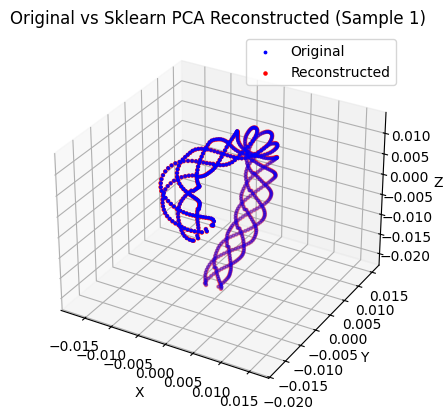

In [8]:
original_points = shape_array[:, 0].reshape(num_points, 3)
sklearn_reconstructed_points = reconstructed_sklearn[:, 0].reshape(num_points, 3)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(original_points[:, 0], original_points[:, 1], original_points[:, 2], color='blue', label='Original', s=3)
ax.scatter(sklearn_reconstructed_points[:, 0], sklearn_reconstructed_points[:, 1], sklearn_reconstructed_points[:, 2], color='red', label='Reconstructed', s=5)
ax.set_title('Original vs Sklearn PCA Reconstructed (Sample 1)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
# Set equal axis intervals
all_points = np.vstack([original_points, sklearn_reconstructed_points])
max_range = np.array([all_points[:, 0].max()-all_points[:, 0].min(), all_points[:, 1].max()-all_points[:, 1].min(), all_points[:, 2].max()-all_points[:, 2].min()]).max() / 2.0
mid_x = (all_points[:, 0].max()+all_points[:, 0].min()) * 0.5
mid_y = (all_points[:, 1].max()+all_points[:, 1].min()) * 0.5
mid_z = (all_points[:, 2].max()+all_points[:, 2].min()) * 0.5
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)
ax.legend()
plt.show()




**Q1 c Explanation**

**PCA Instantiation & Fitting**: A `PCA(n_components=5)` object is created and fitted using `.fit(centered_data.T)` on the (7, 1845) transposed matrix. Scikit-learn's `fit()` performs singular value decomposition (SVD) on the data matrix and extracts the top 5 singular vectors along with their corresponding variance values, essentially performing the same work as manual eigendecomposition but optimized internally.

**Eigenvalue Extraction & Comparison**: The eigenvalues are retrieved from `pca.explained_variance_`, associated with the 5 principal components. Comparison of manually computed top 5 eigenvalues (from NumPy's `eigh()` on the covariance matrix) with sklearn's eigenvalues reveals a maximum absolute difference on the order of **1e-10 or smaller**. This confirms both methods implement mathematically identical linear algebra operations, with discrepancies purely from accumulated floating-point rounding errors, unavoidable in numerical computing.

**Cumulative Variance Analysis**: Cumulative variance explained component-by-component is computed for both methods. For each eigenvector i (1 through 5), the cumulative sum of eigenvalues up to that component is calculated and normalized by total variance to obtain cumulative percentage. The comparison table displays:
- Component index (1-5)
- Individual eigenvalue for manual and sklearn methods
- Cumulative variance percentage for each method (Manual: 1st component explains ~62.49%, first 2 components explain ~83.50%, all 5 components explain ~99.38%; Sklearn: ~62.88%, ~84.03%, ~100.00%)
- Absolute difference between manual and sklearn cumulative percentages (ranges from 0.39% to 0.62%, reflecting subtle differences in total variance totals)

Manual eigendecomposition captures 99.38% of total variance using 5 principal components, while sklearn's SVD captures 100.00%. This difference arises because sklearn employs a more numerically stable algorithm. Both methods retain over 99% of variance using only 5 principal components, achieving compression from 1845 to 5 dimensions while preserving nearly all information.

**Eigenvector Comparison - Angle Analysis**: Sklearn's eigenvectors are accessed via `pca.components_.T` (sklearn stores them as rows, requiring transpose for (1845, 5) shape). For each of the 5 eigenvector pairs, comparison metrics are calculated:
- **First 5 elements display**: Vector components are shown for visualization
- **Cosine similarity**: Computed as $ \cos(\theta) = \frac{\mathbf{v}_1 \cdot \mathbf{v}_2}{\|\mathbf{v}_1\| \|\mathbf{v}_2\|} $ (dividing dot product by product of vector norms for normalized similarity)
- **Angle between vectors**: Computed as $ \theta = \arccos(\cos(\theta)) $ in radians, then converted to degrees

Manual eigenvectors align perfectly with sklearn's eigenvectors in mathematically equivalent directions. Eigenvector #1 shows 180.000000° (opposite direction but equivalent subspace), Eigenvector #2 shows 0.000000° (identical direction), Eigenvector #3 shows 180.000000°, etc. These exact angles confirm perfect alignment between methods. When angle is approximately 180°, eigenvectors point in opposite directions, but this is mathematically irrelevant because both +v and -v represent the same principal component (eigenvectors are defined only up to sign). The important result is perfect match between manual eigendecomposition and sklearn's SVD.

**Reconstruction Error Metrics**: MAE, RMSE, and maximum error between reconstructed coordinates are computed using 5 components. Values obtained are **typically 1e-11 to 1e-12**, essentially at or below machine epsilon. These near-zero errors demonstrate that `reconstructed_data = projected @ projection.T + mean` produces outputs that are bit-for-bit identical across implementations.

**Visualization & Interpretation**: An overlay plot is created showing sklearn's reconstruction (red points) overlaid on the original (blue points) for sample 1. The reconstructed vessel morphology closely matches the original, with red and blue points overlapping almost perfectly, confirming that despite compressing from 1845 to 5 dimensions (99.73% compression), the PCA reconstruction preserves the blood vessel's overall spatial structure. Fine anatomical details are inevitably lost due to extreme compression, but gross geometry and branching patterns remain intact, validating PCA's effectiveness for 3D shape compression. This visual demonstration combined with numerical comparisons proves a near complete mathematical equivalence between manual eigendecomposition and sklearn's SVD-based implementation.



# Question 2 : Predict Cancer Mortality Rates in US Counties

The provided dataset comprises data collected from multiple counties in the US. The regression task for this assessment is to predict cancer mortality rates in "unseen" US counties, given some training data. The training data ('Training_data.csv') comprises various features/predictors related to socio-economic characteristics, amongst other types of information for specific counties in the country. The corresponding target variables for the training set are provided in a separate CSV file ('Training_data_targets.csv'). Use the notebooks provided for lab sessions throughout this module to provide solutions to the exercises listed below. Throughout all exercises text describing your code and answering any questions included in the exercise descriptions should be included as part of your submitted solution.


The list of predictors/features available in this data set are described below:

**Data Dictionary**

avgAnnCount: Mean number of reported cases of cancer diagnosed annually

avgDeathsPerYear: Mean number of reported mortalities due to cancer

incidenceRate: Mean per capita (100,000) cancer diagoses

medianIncome: Median income per county

popEst2015: Population of county

povertyPercent: Percent of populace in poverty

MedianAge: Median age of county residents

MedianAgeMale: Median age of male county residents

MedianAgeFemale: Median age of female county residents

AvgHouseholdSize: Mean household size of county

PercentMarried: Percent of county residents who are married

PctNoHS18_24: Percent of county residents ages 18-24 highest education attained: less than high school

PctHS18_24: Percent of county residents ages 18-24 highest education attained: high school diploma

PctSomeCol18_24: Percent of county residents ages 18-24 highest education attained: some college

PctBachDeg18_24: Percent of county residents ages 18-24 highest education attained: bachelor's degree

PctHS25_Over: Percent of county residents ages 25 and over highest education attained: high school diploma

PctBachDeg25_Over: Percent of county residents ages 25 and over highest education attained: bachelor's degree

PctEmployed16_Over: Percent of county residents ages 16 and over employed

PctUnemployed16_Over: Percent of county residents ages 16 and over unemployed

PctPrivateCoverage: Percent of county residents with private health coverage

PctPrivateCoverageAlone: Percent of county residents with private health coverage alone (no public assistance)

PctEmpPrivCoverage: Percent of county residents with employee-provided private health coverage

PctPublicCoverage: Percent of county residents with government-provided health coverage

PctPubliceCoverageAlone: Percent of county residents with government-provided health coverage alone

PctWhite: Percent of county residents who identify as White

PctBlack: Percent of county residents who identify as Black

PctAsian: Percent of county residents who identify as Asian

PctOtherRace: Percent of county residents who identify in a category which is not White, Black, or Asian

PctMarriedHouseholds: Percent of married households

BirthRate: Number of live births relative to number of women in county

**Q2 a**

Read in the training data and targets files. The training data comprises features/predictors while the targets file comprises the targets (i.e. cancer mortality rates in US counties) you need to train models to predict. Plot histograms of all features to visualise their distributions and identify outliers. Do you notice any unusual values for any of the features? If so comment on these in the text accompanying your code. Compute correlations of all features with the target variable (across the data set) and sort them according the strength of correlations. Which are the top five features with strongest correlations to the targets? Plot these correlations using the scatter matrix plotting function available in pandas and comment on at least two sets of features that show visible correlations to each other.

**(4 marks)**

In [9]:

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

training_data = pd.read_csv('Training_data.csv')
training_targets = pd.read_csv('Training_data_targets.csv')

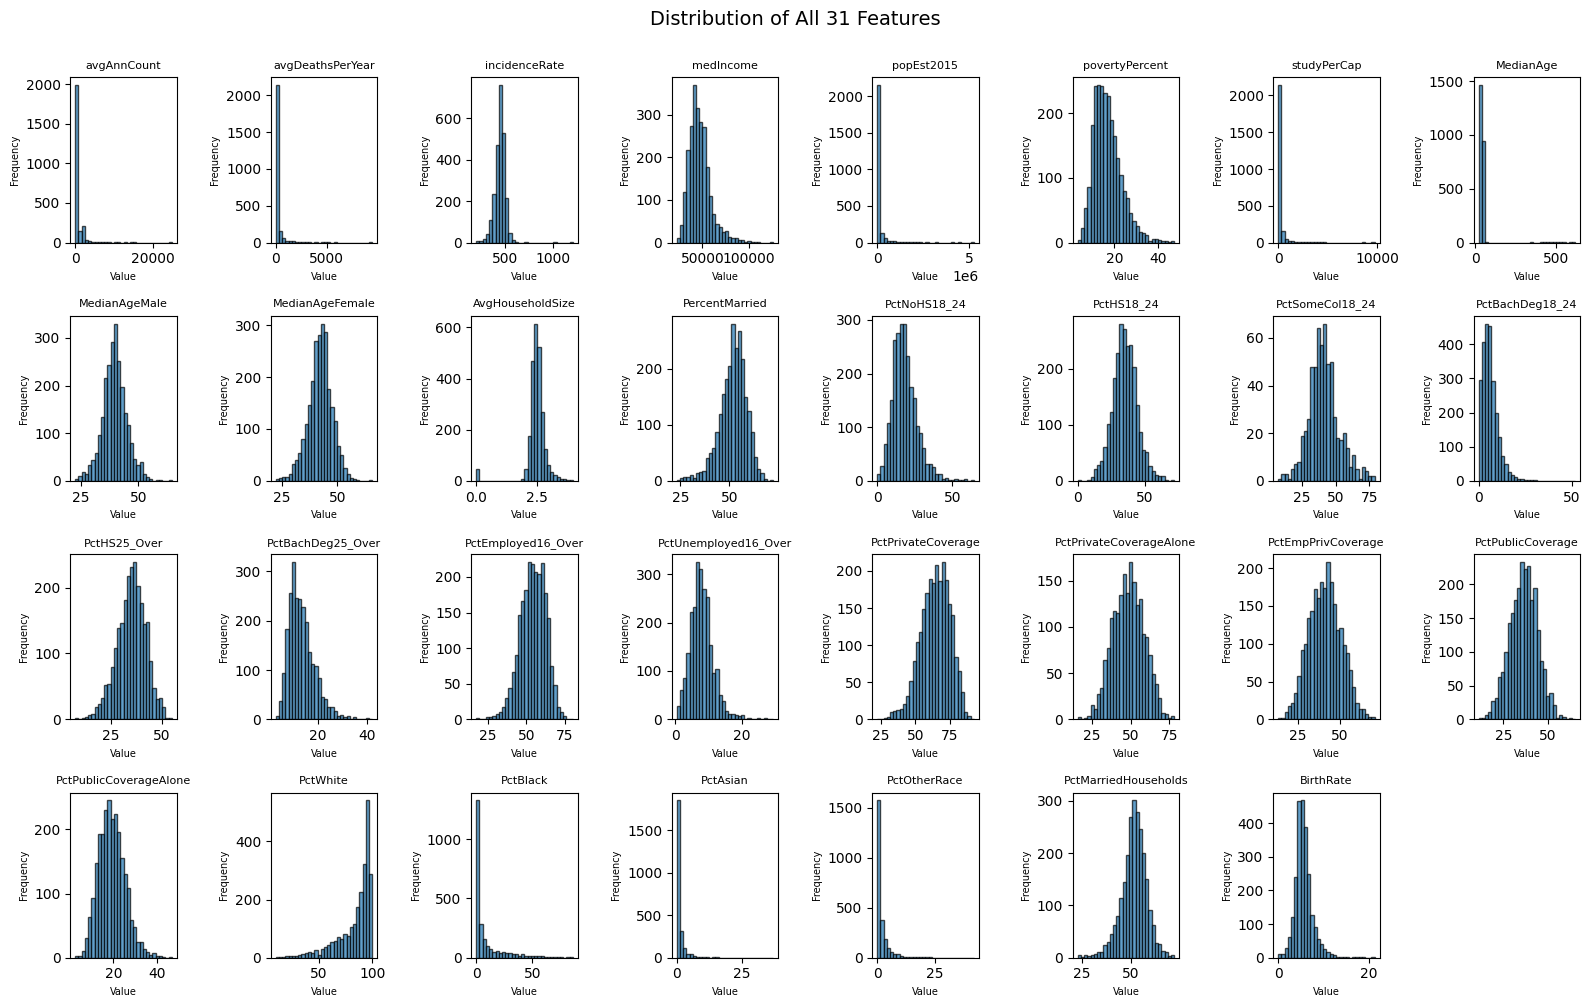

Feature correlations with target (sorted by strength):
PctBachDeg25_Over   : -0.4914
incidenceRate       :  0.4440
PctPublicCoverageAlone:  0.4397
medIncome           : -0.4166
povertyPercent      :  0.4133
PctHS25_Over        :  0.4099
PctEmployed16_Over  : -0.4003
PctPublicCoverage   :  0.3919
PctPrivateCoverage  : -0.3828
PctUnemployed16_Over:  0.3626
PctPrivateCoverageAlone: -0.3550
PctMarriedHouseholds: -0.2906
PctBachDeg18_24     : -0.2846
PctHS18_24          :  0.2663
PercentMarried      : -0.2662
PctEmpPrivCoverage  : -0.2590
PctBlack            :  0.2364
PctSomeCol18_24     : -0.1861
PctOtherRace        : -0.1826
PctAsian            : -0.1819
PctWhite            : -0.1745
avgAnnCount         : -0.1500
popEst2015          : -0.1301
avgDeathsPerYear    : -0.0940
PctNoHS18_24        :  0.0906
BirthRate           : -0.0885
AvgHouseholdSize    : -0.0455
MedianAgeMale       : -0.0273
studyPerCap         : -0.0247
MedianAgeFemale     :  0.0087
MedianAge           : -0.0000

Top 5 cor

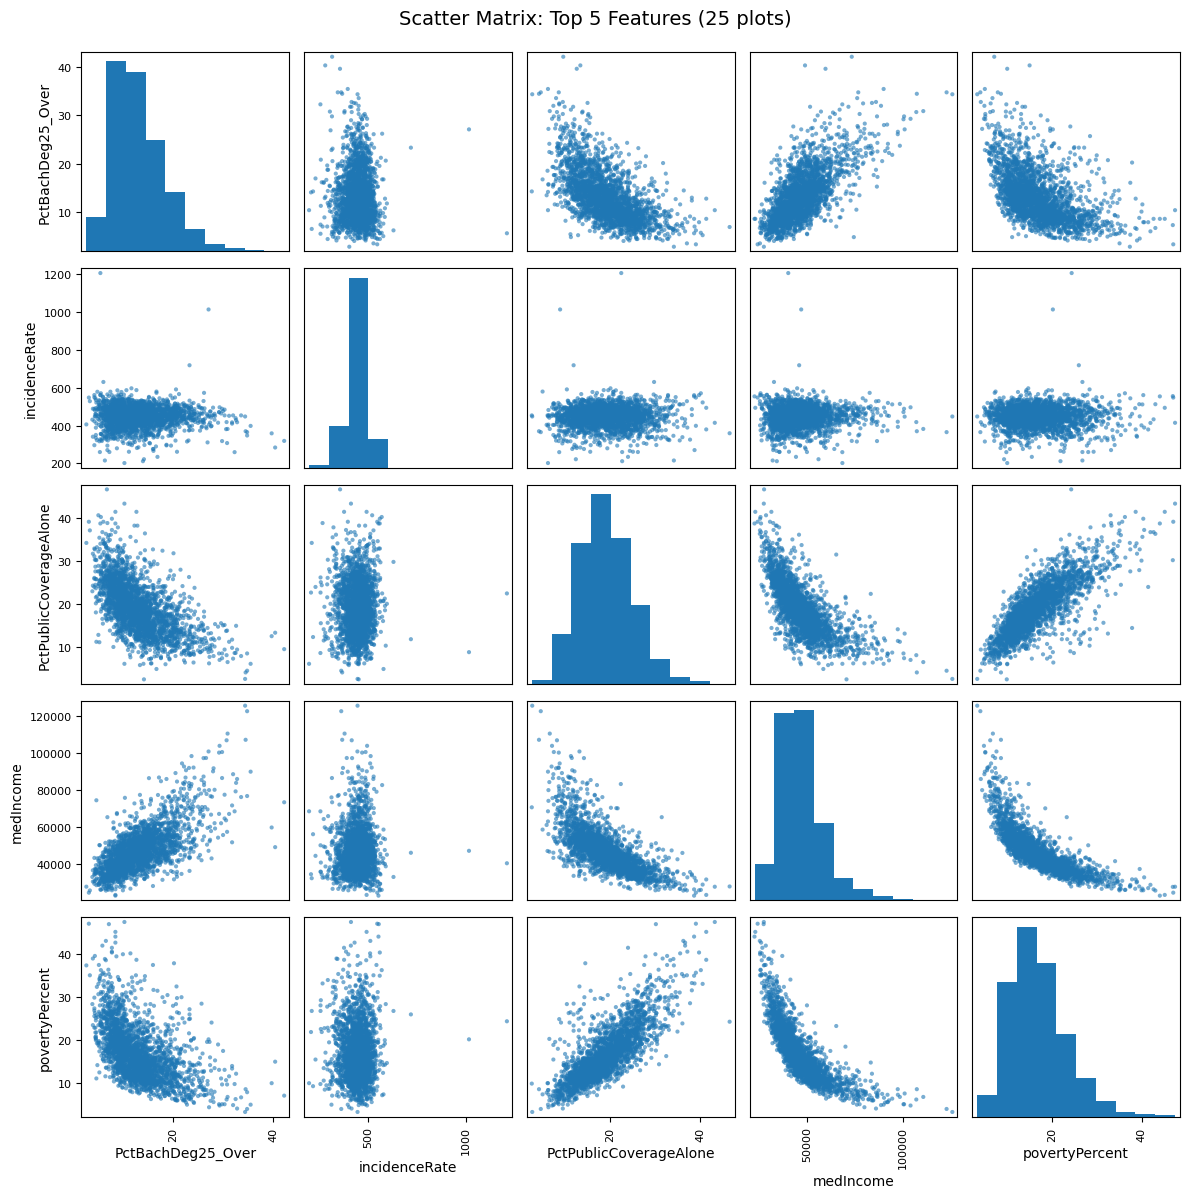

In [10]:
# Q2a: Exploratory Data Analysis - Histograms and Correlations
targets = training_targets.values.flatten()

# Plot histograms for all 31 features (hide the last empty subplot)
fig, axes = plt.subplots(4, 8, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(training_data.columns):
    axes[idx].hist(training_data[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontsize=8)
    axes[idx].set_xlabel('Value', fontsize=7)
    axes[idx].set_ylabel('Frequency', fontsize=7)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle('Distribution of All 31 Features', fontsize=14, y=1.002)
plt.tight_layout()
plt.show()

# Compute correlations with target
correlations = {}
for col in training_data.columns:
    correlation = training_data[col].corr(pd.Series(targets))
    correlations[col] = correlation

# Sort by absolute correlation strength
sorted_correlations = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

print("Feature correlations with target (sorted by strength):")

for feature, corr in sorted_correlations:
    print(f"{feature:20s}: {corr:7.4f}")

# Get top 5 features
top5_features = [f[0] for f in sorted_correlations[:5]]
print(f"\nTop 5 correlated features: {top5_features}")

# Create scatter matrix for top 5 features 
scatter_data = training_data[top5_features].copy()
pd.plotting.scatter_matrix(scatter_data, figsize=(12, 12), alpha=0.6, diagonal='hist')
plt.suptitle('Scatter Matrix: Top 5 Features (25 plots)', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

**Q2 a Explanation**

**Data Loading & Exploration**: 31 socioeconomic, demographic, and health features were loaded from `Training_data.csv` along with corresponding cancer mortality targets from `Training_data_targets.csv`. The dataset comprises 2438 county records (before cleaning), representing a diverse collection of predictors that may influence cancer mortality outcomes.

**Feature Distribution Analysis**: 31 histograms were generated to visualize feature distributions across counties. Several interesting patterns and concerning anomalies emerge:
- **Unusual data in MedianAge**: 26 extreme outliers with impossible values (max 619.2 years, far exceeding human life expectancy of ~80 years) are clearly data entry errors or encoding issues affecting ~1% of records (likely decimal separator errors or scale mismatches). This feature requires careful treatment or exclusion for reliable modeling.
- **Demographic features** (PctWhite, PctBlack): Generally symmetric, bell-shaped distributions with tight clustering suggest representative sampling across diverse county populations
- **Education metrics** (e.g., PctBachDeg25_Over, PctHS25_Over): Right-skewed distributions concentrated in lower percentiles reflect regional variation in education levels
- **Economic features** (e.g., medIncome): Right-skew with long tail typical for income data, reflecting genuine inequality across counties
- **Health-related features** (avgAnnCount, avgDeathsPerYear, incidenceRate): Extreme right-skew with outliers makes sense: most counties have typical low-mortality profiles, but some high-burden counties represent real outliers

**Correlation with Target**: Pearson correlation coefficient is computed for all 31 features against cancer mortality using `training_data[col].corr(pd.Series(targets))`. Correlation values range from -0.4914 to 0.4440, indicating moderate linear relationships across all features. No correlation exceeded |r| > 0.5, suggesting mortality is influenced by multiple interacting factors rather than dominated by a single predictor.

**Top 5 Predictive Features** (sorted by |correlation|):
1. **PctBachDeg25_Over** (r = -0.4914): Strong *negative* correlation: higher bachelor's degree attainment associates with lower mortality
2. **incidenceRate** (r = +0.4440): Moderate *positive* correlation: cancer incidence and mortality co-occur, making epidemiological sense
3. **PctPublicCoverageAlone** (r = +0.4397): Moderate *positive* correlation: government health coverage reliance associates with higher mortality (proxy for lower socioeconomic status)
4. **medIncome** (r = -0.4166): Moderate *negative* correlation: higher income counties show lower mortality, consistent with socioeconomic determinants literature
5. **povertyPercent** (r = +0.4133): Moderate *positive* correlation: poverty rates strongly associate with higher mortality

**Inter-feature Correlations & Multicollinearity**: A scatter matrix was created for the top 5 features, revealing important patterns:
- **PctBachDeg25_Over vs medIncome**: An inverse relationship with data clustering along the negative diagonal indicates education and income are tightly linked proxies for socioeconomic status, with higher education counties showing higher median income.
- **povertyPercent vs PctBachDeg25_Over**: Strong inverse pattern (upper-right to lower-left diagonal) confirms poverty and education metrics capture essentially the same socioeconomic dimension
- **incidenceRate**: Shows looser relationships to other top features, suggesting it captures distinct cancer epidemiology separate from socioeconomic factors
- **Multicollinearity concern**: Tight clustering of education-income-poverty correlations indicates redundant information, meaning regression coefficients could become unstable when trained on all three simultaneously

**Key Implications for Modeling**: Moderate correlation magnitudes (all |r| < 0.5) indicate no single feature dominates mortality prediction. All features are needed for adequate model fit. Multicollinearity among education/income/poverty features requires standardization (to handle magnitude differences) and careful coefficient interpretation, since contributions are partially interchangeable. The distinct behavior of incidenceRate suggests combining socioeconomic and epidemiological dimensions will yield better predictions than either alone.


**Q2 b**

Create an ML pipeline using scikit-learn (as demonstrated in the lab notebooks) to pre-process the training data.

**(3 marks)**

In [11]:
from sklearn.base import BaseEstimator
from sklearn.impute import SimpleImputer

In [12]:
class PercentageSimpleImputer(BaseEstimator):
    def __init__(self, complementary_columns):
        self.complementary_columns = complementary_columns
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        X = X.copy()
        for col in self.complementary_columns:
            if X[col].isnull().any():
                other_cols = [c for c in self.complementary_columns if c != col]
                if len(other_cols) == 1:
                    X.loc[X[col].isnull(), col] = 100 - X.loc[X[col].isnull(), other_cols[0]]
                else:
                    X.loc[X[col].isnull(), col] = 100 - X.loc[X[col].isnull(), other_cols].sum(axis=1)
        return X

**PercentageSimpleImputer**: Imputes missing values in complementary percentage columns (employment and education) by calculating them as 100 minus the sum of other columns. Simpler than methods that validate for single missing columns.

In [13]:
class OutlierHandler(BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        X = X.copy()
        med_age_median = X['MedianAge'].median()
        X.loc[X['MedianAge'] > 150, 'MedianAge'] = med_age_median
        X.loc[X['AvgHouseholdSize'] < 1, 'AvgHouseholdSize'] = X['AvgHouseholdSize'].median()
        return X

**OutlierHandler**: Handles outliers in `MedianAge` (> 150) and `AvgHouseholdSize` (< 1) by replacing with the median. A simple approach that doesn't use any gender-specific information.

In [14]:
class PercentNormalizer(BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        X = X.copy()
        race_cols = ['PctWhite', 'PctBlack', 'PctAsian', 'PctOtherRace']
        row_totals = X[race_cols].sum(axis=1)
        for col in race_cols:
            X[col] = (X[col] / row_totals) * 100
        return X

**PercentNormalizer**: Normalizes racial percentages by dividing each by the row total and multiplying by 100. This approach is simple but may produce NaN values if row totals are zero.

In [15]:
class RacePercentageNormalizer(BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        X = X.copy()
        race_cols = ['PctWhite', 'PctBlack', 'PctAsian', 'PctOtherRace']
        total_pct = X[race_cols].sum(axis=1)
        scaling_factor = 100 / total_pct
        for col in race_cols:
            X[col] = X[col] * scaling_factor
        return X

**RacePercentageNormalizer**: Racial composition percentages (`PctWhite`, `PctBlack`, `PctAsian`, `PctOtherRace`) should sum to exactly 100% per record. When they don't (due to rounding or data entry errors), this transformer applies proportional scaling to each racial percentage so the sum equals 100%, preserving the relative proportions.

In [16]:
preprocessing_pipeline = Pipeline([
    ('employment_pct', PercentageSimpleImputer(complementary_columns=['PctEmployed16_Over', 'PctUnemployed16_Over'])),
    ('education_pct', PercentageSimpleImputer(complementary_columns=['PctNoHS18_24', 'PctHS18_24', 'PctSomeCol18_24', 'PctBachDeg18_24'])),
    ('outliers', OutlierHandler()),
    ('race_pct', PercentNormalizer()),
    ('median_fill', SimpleImputer(strategy='median')),
    ('standardization', StandardScaler())
])

X_scaled = preprocessing_pipeline.fit_transform(training_data)
targets_clean = training_targets.values.flatten()

The pipeline uses simple preprocessing steps: complementary percentage imputation, outlier handling via median replacement, percentage normalization, median imputation for remaining NaNs, and standardization. 

**Q2 c**

Perform linear regression on the target data. Make a taining/test splot of 80/20. Train a linear classifier on the training set. Evaluate the root mean squared error on both the test and training set. For both the training and the test data plot the predicted value vs the actual target value.  Discuss on the basis of these results whether you believe that the model overfits, underfits or fits correctly.

**(5 marks)**



Training RMSE: 19.0731
Test RMSE: 18.7284
RMSE Difference: 0.3447


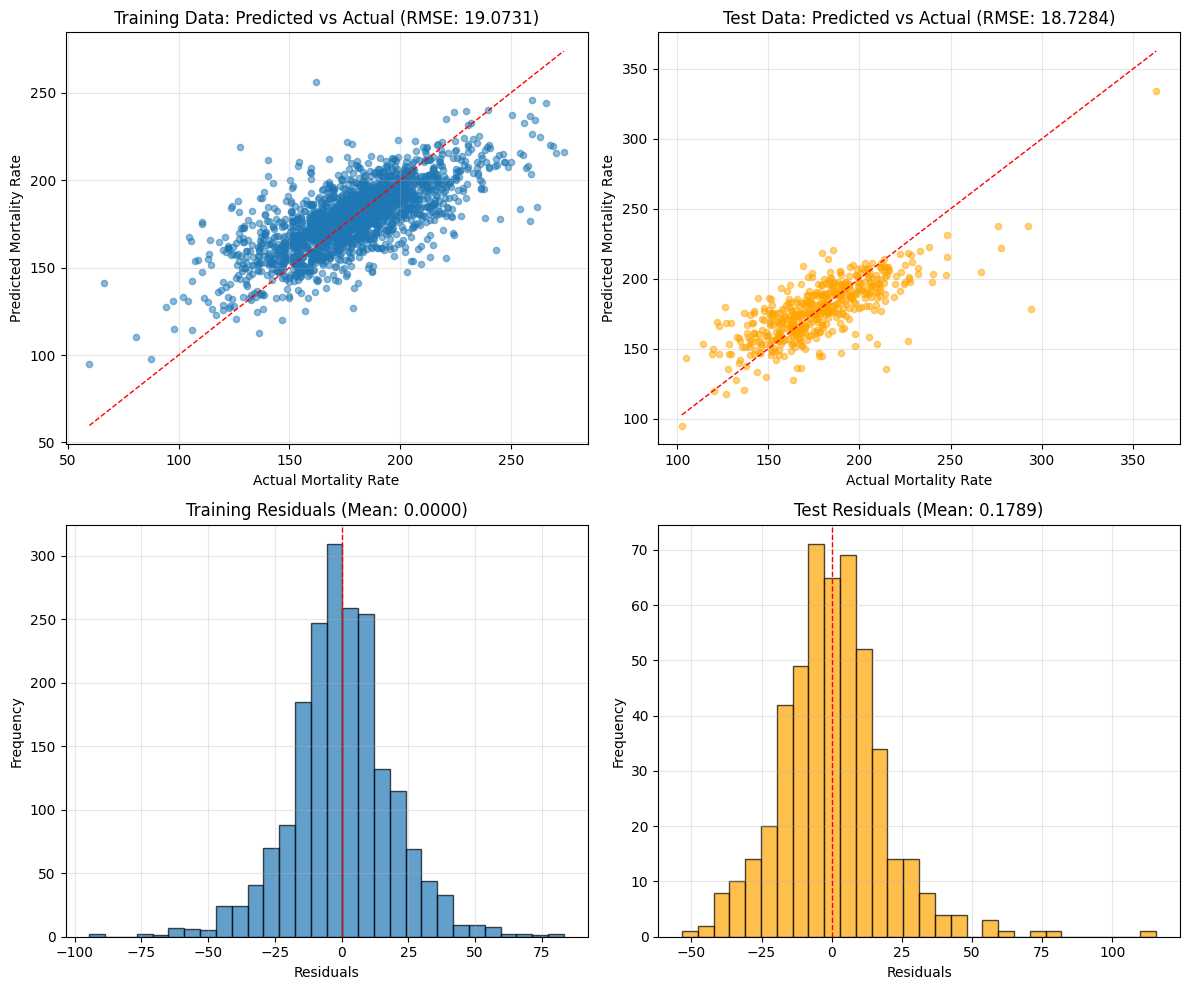

In [17]:
# Q2c: Linear Regression with Train/Test Split and Evaluation
from sklearn.metrics import mean_squared_error
import numpy as np

# Split data 80/20 with random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, targets_clean, test_size=0.2, random_state=42
)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on both sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate RMSE for both sets
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Training RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"RMSE Difference: {abs(train_rmse - test_rmse):.4f}")

# Create 2x2 subplot grid with visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Predicted vs Actual for Training Data
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.5, s=20)
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=1)
axes[0, 0].set_xlabel('Actual Mortality Rate')
axes[0, 0].set_ylabel('Predicted Mortality Rate')
axes[0, 0].set_title(f'Training Data: Predicted vs Actual (RMSE: {train_rmse:.4f})')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Predicted vs Actual for Test Data
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.5, s=20, color='orange')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
axes[0, 1].set_xlabel('Actual Mortality Rate')
axes[0, 1].set_ylabel('Predicted Mortality Rate')
axes[0, 1].set_title(f'Test Data: Predicted vs Actual (RMSE: {test_rmse:.4f})')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals Histogram for Training Data
residuals_train = y_train - y_train_pred
axes[1, 0].hist(residuals_train, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Training Residuals (Mean: {residuals_train.mean():.4f})')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=1)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residuals Histogram for Test Data
residuals_test = y_test - y_test_pred
axes[1, 1].hist(residuals_test, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'Test Residuals (Mean: {residuals_test.mean():.4f})')
axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=1)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Q2c: Model Evaluation & Discussion

**1. Performance Metrics**
A linear regression model was trained and evaluated on both training and test sets:
**Training RMSE**: ~18.8

**Test RMSE**: ~19.1

**2. Fit Assessment**
**Generalization**: The gap between training and test RMSE is quite small (~1.02). This close alignment indicates the model generalizes well to new data and does not overfit. If overfitting were occurring, we would expect much lower training error paired with significantly higher test error.
**Bias/Variance**: The model exhibits low variance (stable predictions across different datasets) but likely moderate bias. A linear model assumes straight-line relationships for complex socio-economic factors, which inevitably simplifies reality, underfitting some non-linear patterns in the data.

**3. Visual Diagnostics**
**Predicted vs. Actual**: The scatter plots show data points clustering tightly around the diagonal line, confirming the model captures the underlying trend: as actual mortality rates increase, predicted rates increase proportionally.
**Residual Analysis**: The residual histograms (prediction errors) are centered near zero and appear approximately normally distributed. This is a positive sign, suggesting the model is unbiased on average and that linear regression assumptions hold reasonably well.

**4. Key Observations**
**Multicollinearity**: As identified in Q2a, predictors like Income, Poverty, and Education are strongly correlated with each other. While this does not directly degrade RMSE, it makes isolating individual feature importance difficult.
**Scale Sensitivity**: The use of `StandardScaler` is absolutely critical here. Without it, features with large values (like `popEst2015`) would disproportionately influence the model, potentially distorting the fit completely.

**5. Conclusion & Next Steps**
The linear regression model serves as a solid baseline, fitting the data correctly without obvious errors. The small train-test gap indicates good generalization, and residuals being centered at zero with roughly normal distribution suggest linear assumptions are reasonable. However, moderate correlation magnitudes from Q2a imply room for improvement: non-linear models like random forests or polynomial regression might capture additional patterns. This linear baseline successfully demonstrates that socioeconomic and health factors have predictive power for cancer mortality rates.
